In [23]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
# Import RandomFlip and RandomRotation from the preprocessing module
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, LeakyReLU, RandomFlip, RandomRotation
from tensorflow.keras.layers import Conv2D, MaxPool2D, LeakyReLU

In [24]:
# import kagglehub

# # https://www.kaggle.com/datasets/joydippaul/mpox-skin-lesion-dataset-version-20-msld-v20(Multiclass)

# # Download latest version
# path1 = kagglehub.dataset_download("joydippaul/mpox-skin-lesion-dataset-version-20-msld-v20")

# # https://www.kaggle.com/datasets/nafin59/monkeypox-skin-lesion-dataset
# # Download latest version
# path2 = kagglehub.dataset_download("nafin59/monkeypox-skin-lesion-dataset")


# print("Path to dataset files:", path1)
# print("Path to dataset files:", path2)

In [25]:
IMG_SIZE = (224, 224) # resolution
directory = "/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Augmented Images/Augmented Images/FOLDS_AUG/fold2_AUG/Train"
BATCH_SIZE = 32
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)

validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)

Found 7126 files belonging to 6 classes.
Using 6414 files for training.
Found 7126 files belonging to 6 classes.
Using 712 files for validation.


In [26]:
class_names = train_dataset.class_names
all_labels = []

for images, labels in train_dataset:
    all_labels.extend(labels.numpy())

class_counts = np.bincount(all_labels)
if len(class_counts) < len(class_names):
    class_counts = np.pad(class_counts, (0, len(class_names) - len(class_counts)))

for i, cls in enumerate(class_names):
    print(f"{cls}: {class_counts[i]}")

Chickenpox: 653
Cowpox: 591
HFMD: 1384
Healthy: 994
Measles: 511
Monkeypox: 2281


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


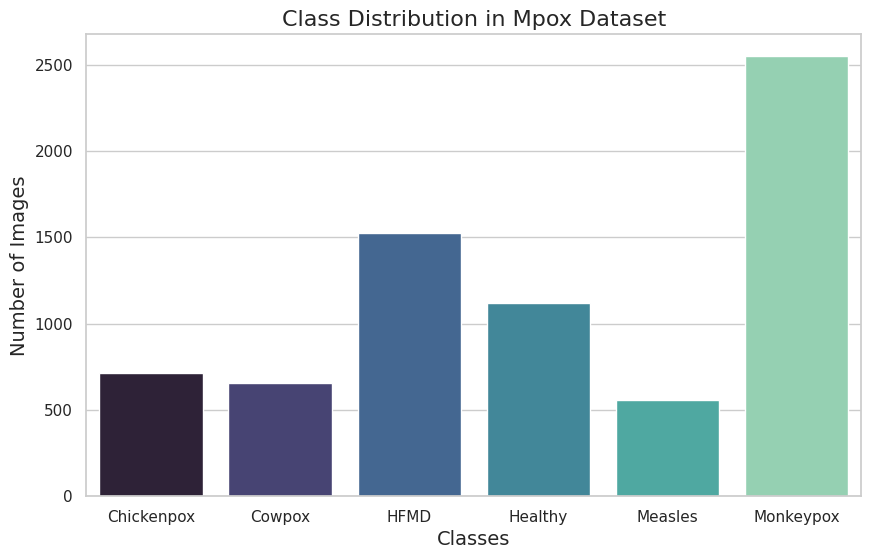

In [27]:
# Set seaborn theme
sns.set_theme(style="whitegrid")

# Get class names
class_names = train_dataset.class_names

# Count images in each class directory
Data_imbalance = []
for folder in class_names:
    files = gb.glob(pathname=os.path.join(directory, folder, "*.*"))
    Data_imbalance.append(len(files))

# Plot class imbalance
plt.figure(figsize=(10, 6))
sns.barplot(x=class_names, y=Data_imbalance, palette="mako")
plt.title("Class Distribution in Mpox Dataset", fontsize=16)
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.show()

In [28]:
# Assuming class_counts = [count_chickenpox, count_cowpox, count_hfmd, count_healthy, count_measles, count_monkeypox]
# and class_names = ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
total = sum(class_counts)
num_classes = len(class_counts)

class_weight = {
    i: (1 / class_counts[i]) * (total / num_classes)
    for i in range(num_classes)
}

# Pretty print
for i, cls in enumerate(class_names):
    print(f'Weight for class {i} ({cls}): {class_weight[i]:.2f}')

Weight for class 0 (Chickenpox): 1.64
Weight for class 1 (Cowpox): 1.81
Weight for class 2 (HFMD): 0.77
Weight for class 3 (Healthy): 1.08
Weight for class 4 (Measles): 2.09
Weight for class 5 (Monkeypox): 0.47


In [29]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])

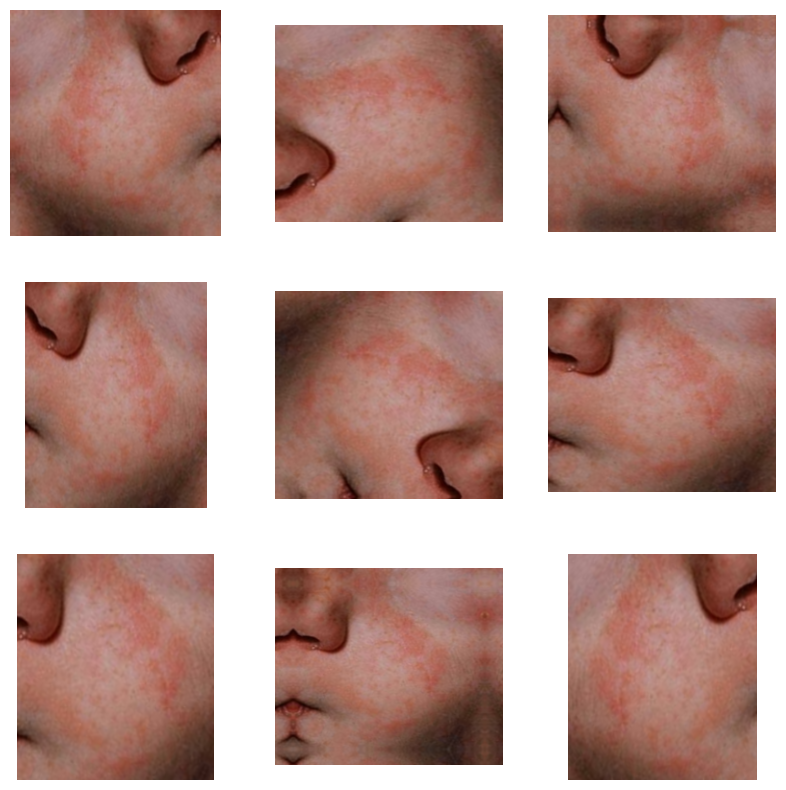

In [30]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

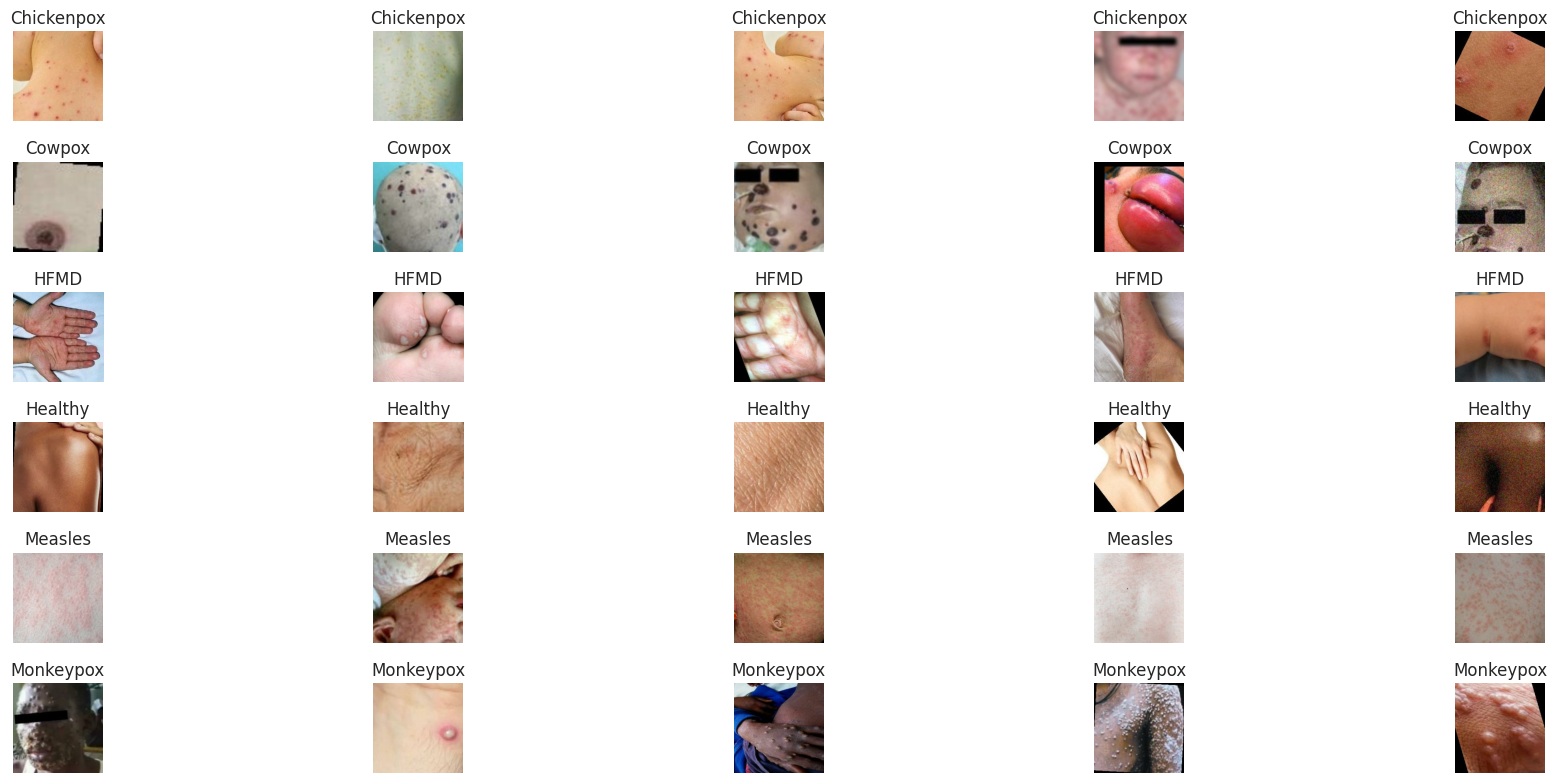

In [31]:
import matplotlib.pyplot as plt

# Define class names
class_names = ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
class_samples = {cls: [] for cls in class_names}

# Go through multiple batches to gather enough samples
for images, labels in train_dataset.take(10):  # You can increase `.take()` if needed
    for image, label in zip(images, labels):
        label_name = class_names[label.numpy()]
        if len(class_samples[label_name]) < 5:
            class_samples[label_name].append(image.numpy().astype("uint8"))
    # Break early if we have 5 images for every class
    if all(len(imgs) == 5 for imgs in class_samples.values()):
        break

# Safely plot only available samples
plt.figure(figsize=(20, 8))
for idx, cls in enumerate(class_names):
    for i in range(len(class_samples[cls])):  # Avoid IndexError
        plt.subplot(len(class_names), 5, idx * 5 + i + 1)
        plt.imshow(class_samples[cls][i])
        plt.axis("off")
        plt.title(cls)

plt.tight_layout()
plt.show()

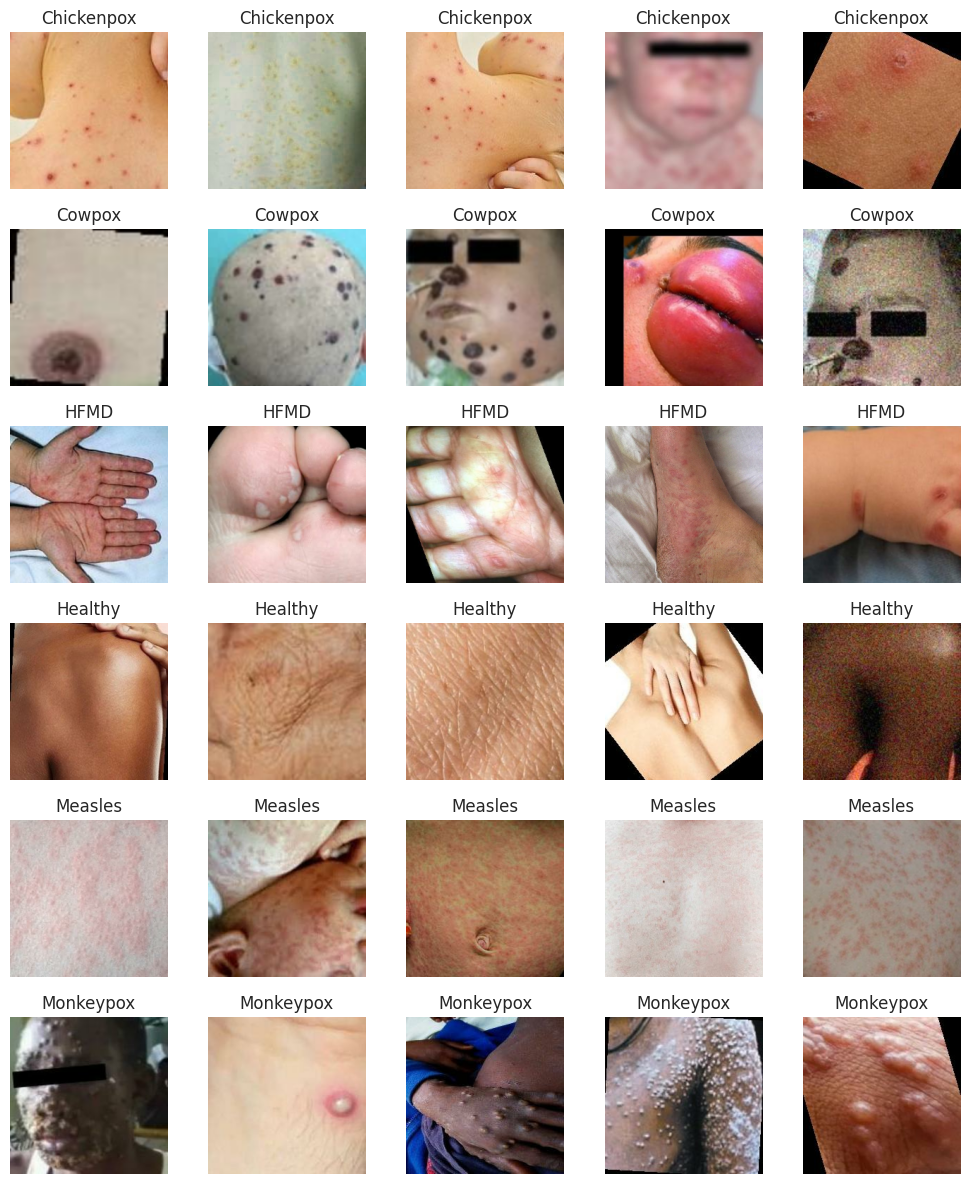

In [32]:
# Assuming class_names and class_samples already defined
# class_names = ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
# class_samples = {cls: [image1, image2, ...]}

plt.figure(figsize=(20, len(class_names) * 2))

# Max samples to show per class
max_samples = 10

for row, cls in enumerate(class_names):
    num_samples = min(max_samples, len(class_samples[cls]))
    for i in range(num_samples):
        plt.subplot(len(class_names), max_samples, row * max_samples + i + 1)
        plt.imshow(class_samples[cls][i])
        plt.axis("off")
        plt.title(cls)

plt.tight_layout()
plt.show()

In [33]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

In [34]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Load the base VGG19 model
base_model = VGG19(input_shape=(224,224, 3), include_top=False, weights='imagenet')
# base_model.trainable = False  # Freeze the base model

base_model.trainable = True
for layer in base_model.layers[:-4]:  # freeze all but last few
    layer.trainable = False


# Build the model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Add early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [35]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    class_weight=class_weight,
    callbacks=[early_stopping]
)

# Evaluate the model on the validation dataset
test_loss, test_accuracy = model.evaluate(validation_dataset)

print(f"\n✅ Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"🧪 Testing Loss: {test_loss:.4f}")

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.3538 - loss: 1.8877 - val_accuracy: 0.7458 - val_loss: 0.7631
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.7318 - loss: 0.6501 - val_accuracy: 0.8638 - val_loss: 0.4634
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.8840 - loss: 0.2880 - val_accuracy: 0.8975 - val_loss: 0.3361
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9238 - loss: 0.2075 - val_accuracy: 0.9003 - val_loss: 0.3361
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9539 - loss: 0.1189 - val_accuracy: 0.9382 - val_loss: 0.2587
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9628 - loss: 0.0930 - val_accuracy: 0.9368 - val_loss: 0.2374
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9701 - loss: 0.0759 - val_accuracy: 0.9410 - val_loss: 0.2043
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9760 - loss: 0

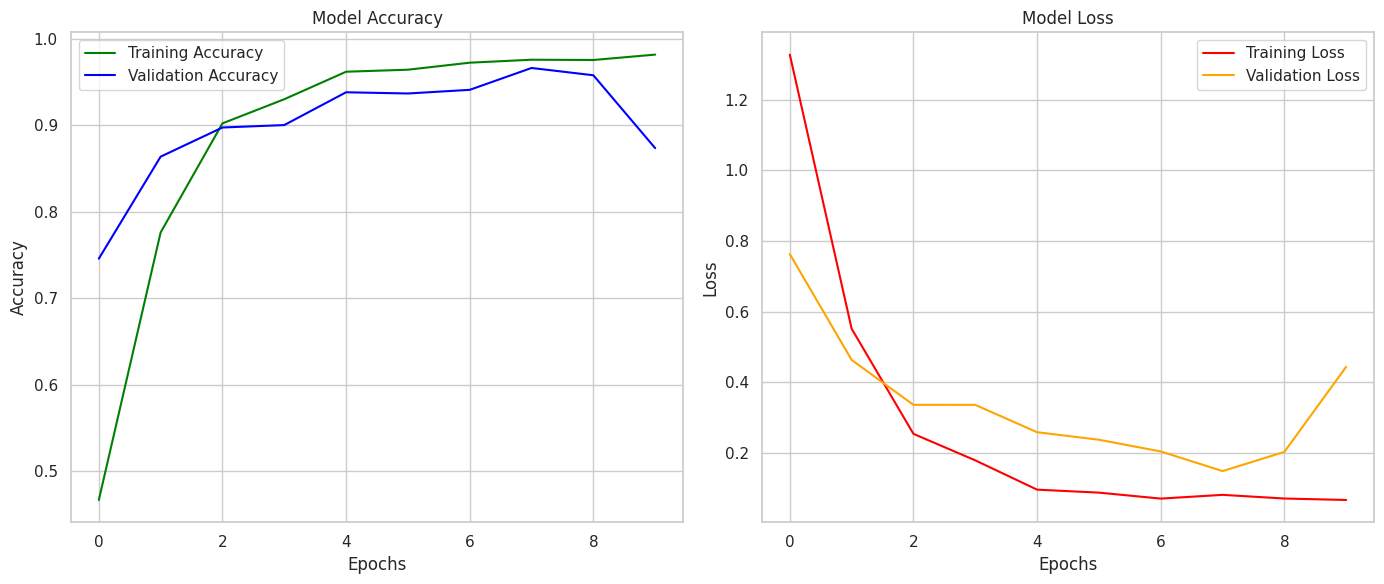

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step


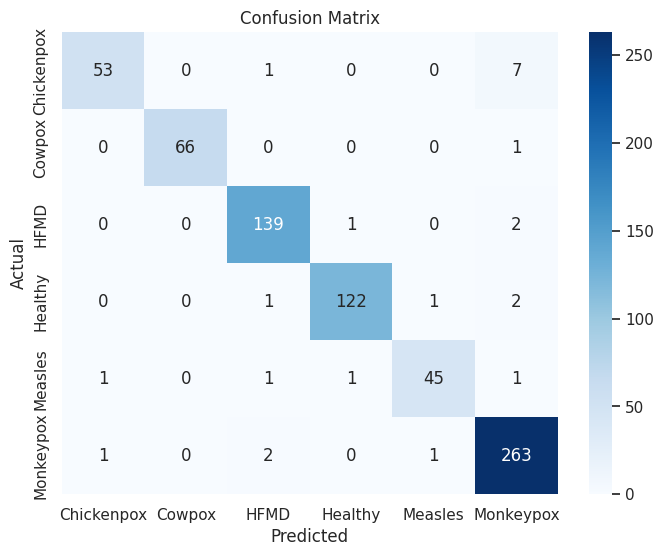

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [38]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

  Chickenpox       0.96      0.87      0.91        61
      Cowpox       1.00      0.99      0.99        67
        HFMD       0.97      0.98      0.97       142
     Healthy       0.98      0.97      0.98       126
     Measles       0.96      0.92      0.94        49
   Monkeypox       0.95      0.99      0.97       267

    accuracy                           0.97       712
   macro avg       0.97      0.95      0.96       712
weighted avg       0.97      0.97      0.97       712

